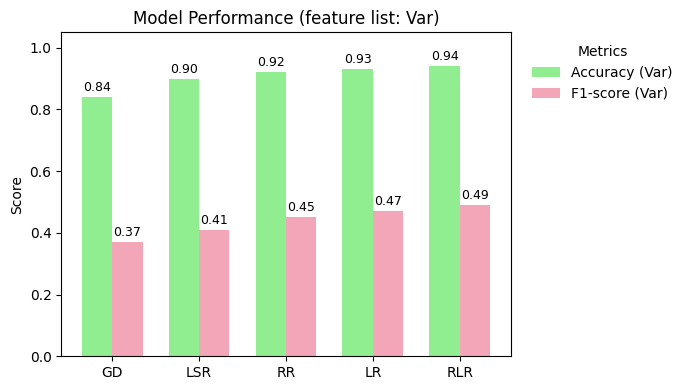

In [8]:
#### WE WILL NEED TO DELETE THAT


import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["GD", "LSR", "RR", "LR", "RLR"]

# Results for best subset ("Var")
accuracy_var = [0.84, 0.90, 0.92, 0.93, 0.94]
f1_var       = [0.37, 0.41, 0.45, 0.47, 0.49]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7, 4))

bars1 = plt.bar(
    x - width/2, accuracy_var, width,
    color="#90EE90", label="Accuracy (Var)"
)
bars2 = plt.bar(
    x + width/2, f1_var, width,
    color="#F4A6B9", label="F1-score (Var)"
)

# Add value labels on each bar
for bars in (bars1, bars2):
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            f"{y:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Labels and style
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Model Performance (feature list: Var)")
plt.xticks(x, models)

# --- Move the legend outside the plot ---
plt.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    title="Metrics"
)

plt.tight_layout()
plt.show()


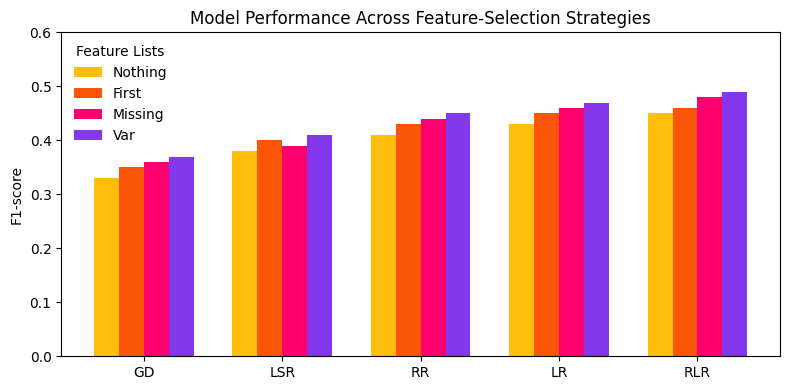

In [6]:
#### WE WILL NEED TO DELETE THAT

import matplotlib.pyplot as plt
import numpy as np

models = ["GD", "LSR", "RR", "LR", "RLR"]
lists = ["Nothing", "First", "Missing", "Var"]

# Example F1-scores
f1_scores = np.array([
    [0.33, 0.35, 0.36, 0.37],  # GD
    [0.38, 0.40, 0.39, 0.41],  # LSR
    [0.41, 0.43, 0.44, 0.45],  # RR
    [0.43, 0.45, 0.46, 0.47],  # LR
    [0.45, 0.46, 0.48, 0.49],  # RLR
])

x = np.arange(len(models))
width = 0.18
colors = ["#ffbe0b", "#fb5607", "#ff006e", "#8338ec"]

plt.figure(figsize=(8, 4))
for i, (label, color) in enumerate(zip(lists, colors)):
    plt.bar(x + (i - 1.5) * width, f1_scores[:, i], width, label=label, color=color)

plt.ylabel("F1-score")
plt.ylim(0, 0.6)
plt.title("Model Performance Across Feature-Selection Strategies")
plt.xticks(x, models)
plt.legend(frameon=False, title="Feature Lists")
plt.tight_layout()
plt.show()


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ---- Load JSON file ----
with open("results_metrics.json", "r") as f:
    data = json.load(f)

models = data["models"]
lists = data["feature_lists"]

# Convert f1 data (dict → NumPy array)
f1_scores = np.array([data["f1"][m] for m in models])

# ---- Plot ----
x = np.arange(len(models))
width = 0.18
colors = ["#ffbe0b", "#fb5607", "#ff006e", "#8338ec"]

plt.figure(figsize=(8, 4))
for i, (label, color) in enumerate(zip(lists, colors)):
    # center the bars dynamically
    plt.bar(
        x + (i - (len(lists)-1)/2) * width,
        f1_scores[:, i],
        width,
        label=label,
        color=color
    )

plt.ylabel("F1-score")
plt.ylim(0, 0.6)
plt.title("Model Performance Across Feature-Selection Strategies")
plt.xticks(x, models)
plt.legend(frameon=False, title="Feature Lists")
plt.tight_layout()
plt.show()


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ---- 1) Load JSON ----
with open("results_metrics.json", "r") as f:
    data = json.load(f)

models = data["models"]
feature_lists = data["feature_lists"]
f1_dict = data["f1"]
acc_dict = data["accuracy"]

# ---- 2) Build matrices (n_models x n_feature_lists) ----
f1_matrix = np.array([f1_dict[m] for m in models])        # shape (5, 4)
acc_matrix = np.array([acc_dict[m] for m in models])      # shape (5, 4)

# ---- 3) Find which feature list has the best F1 overall ----
# average F1 over models, one value per feature list
mean_f1_per_list = f1_matrix.mean(axis=0)                 # shape (4,)
best_list_idx = int(np.argmax(mean_f1_per_list))
best_list_name = feature_lists[best_list_idx]

print("Best feature list based on mean F1:", best_list_name)

# ---- 4) Extract accuracy + F1 for that list ----
f1_best = f1_matrix[:, best_list_idx]     # shape (5,)
acc_best = acc_matrix[:, best_list_idx]   # shape (5,)

# ---- 5) Plot ----
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7, 4))

bars1 = plt.bar(
    x - width/2, acc_best, width,
    color="#90EE90", label=f"Accuracy ({best_list_name})"
)
bars2 = plt.bar(
    x + width/2, f1_best, width,
    color="#F4A6B9", label=f"F1-score ({best_list_name})"
)

# add value labels
for bars in (bars1, bars2):
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y + 0.01,
            f"{y:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title(f"Model Performance (feature list: {best_list_name})")
plt.xticks(x, models)

# put legend outside
plt.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    title="Metrics"
)

plt.tight_layout()
plt.show()
